# SE232 WI26 Final Project
*Jeremy Doan A16844657*

**Attributions:**

All code used was repurposed from previously developed code. All borrowed code structures were adapted from PyTorch tutorials.

In [1]:
# ! pip uninstall torch torchvision torchaudio -y
# ! pip install torch --index-url https://download.pytorch.org/whl/cu130
# ! pip install numpy
# ! pip install scikit-learn
# ! pip install scipy
# ! pip install matplotlib
# ! pip install pandas

In [2]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Import libraries
import os
import numpy as np
import torch
import sys
import matplotlib.pyplot as plt


# Import helper scripts
base_pth = '/content/drive/MyDrive/se232/Final/' # colab
# base_pth = '/home/jhdoan/Final' # jupyterhub
sys.path.append(base_pth)
os.chdir(base_pth)
from global_var import config
from dataset import Dataset
from plots import plot_displacement_contours, plot_deformed_shape, plot_pred_vs_target, plot_deformed_comparison
from unet import UNet
from loss_func import test_energy_loss


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Directory: \n{os.getcwd()}\n")
print(f"Device: \n{device}\n")
print(f"Global Variables: \n{config}\n")

Directory: 
/content/drive/MyDrive/se232/Final

Device: 
cuda

Global Variables: 
{'ngpu': 1, 'lr': 0.005, 'lr_min': 0.0001, 'weight_mse': 1.0, 'weight_en': 0.001, 'n_epochs': 200, 'start_epoch': 0, 'beta1': 0.9, 'workers': 0, 'batch_size': 256, 'dataroot': '/content/drive/MyDrive/se232/Final/dataset.mat', 'main_dir': '/content/drive/MyDrive/se232/Final/Results/', 'unet_name': ''}



## Load Data

In [5]:
train_dataset, test_dataset = Dataset.get_dataset(config["dataroot"]) # Train/test samples
B, D, psi = Dataset.get_constants(config["dataroot"]) # Constants for PDE

In [6]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}\n")

print(f"B shape: {B.shape}")
print(f"D shape: {D.shape}")
print(f"Shape function shape: {psi.shape}")

Train dataset size: 1464
Test dataset size: 366

B shape: torch.Size([3, 2, 1029, 1029])
D shape: torch.Size([3, 3])
Shape function shape: torch.Size([2500, 49, 21])


In [7]:
train_dataloader = Dataset.get_dataloader(train_dataset, shuffle_data=True)
test_dataloader = Dataset.get_dataloader(test_dataset, shuffle_data=False)

In [8]:
t_vals = [item[1] for item in train_dataset]
stacked = torch.stack(t_vals)
print(f"Dataset Tractions Min/Max: [{stacked.min().item()}, {stacked.max().item()}]")

u_vals = [item[2] for item in train_dataset]
stacked = torch.stack(u_vals)
print(f"Dataset Displacements Min/Max: [{stacked.min().item()}, {stacked.max().item()}]")

nodes_grid, t_grid, u_grid = train_dataset[0]
print(f"Nodes shape: {nodes_grid.shape}")

Dataset Tractions Min/Max: [-1.0, 1.0]
Dataset Displacements Min/Max: [-1.0, 1.0]
Nodes shape: torch.Size([2, 49, 21])


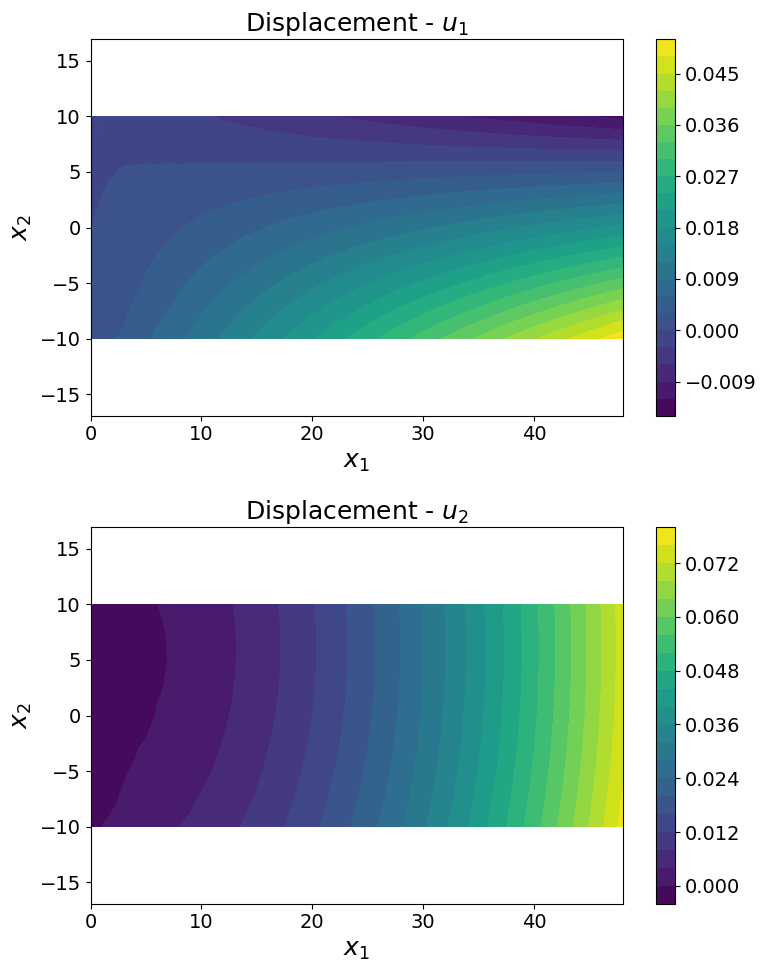

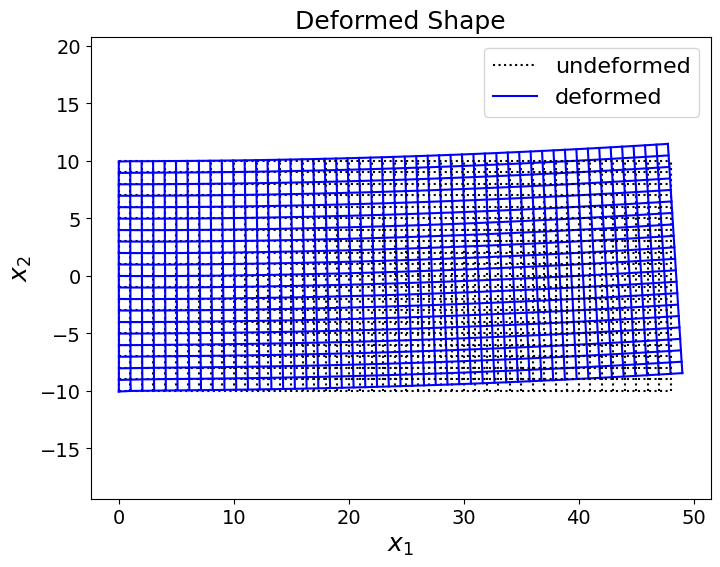

In [9]:
# Plots
L = 48.0
W = 20.0

# Contour plots
plot_displacement_contours(u_grid, L, W)

# Deformed shape
plot_deformed_shape(u_grid, L, W, scale=20.0)

## Train Model

In [10]:
# Train
!python unet_main.py

Rank 0 out of 1 GPUs
LR after resume: 0.005
Training set size: 1464
REMINDER: STARTING FROM EPOCH 0
[0/200] [4/5] UNet Loss: 13251.908527, Val Loss: 611.0881958007812 LR = 5.00e-03 
[10/200] [4/5] UNet Loss: 4.665052, Val Loss: 3.103879451751709 LR = 5.00e-03 
[20/200] [4/5] UNet Loss: 0.143330, Val Loss: 0.09612434357404709 LR = 5.00e-03 
[30/200] [4/5] UNet Loss: 0.588409, Val Loss: 0.11259569227695465 LR = 5.00e-03 
[40/200] [4/5] UNet Loss: 0.019930, Val Loss: 0.017674505710601807 LR = 5.00e-03 
Checkpoint saved at epoch 50 to /content/drive/MyDrive/se232/Final/Results/Train_Results/checkpoint_epoch_50.pth
[50/200] [4/5] UNet Loss: 0.882020, Val Loss: 0.3716041147708893 LR = 5.00e-03 
[60/200] [4/5] UNet Loss: 0.017607, Val Loss: 0.014524241909384727 LR = 4.00e-03 
[70/200] [4/5] UNet Loss: 0.015451, Val Loss: 0.015941010788083076 LR = 4.00e-03 
[80/200] [4/5] UNet Loss: 0.014969, Val Loss: 0.011264456436038017 LR = 4.00e-03 
[90/200] [4/5] UNet Loss: 0.012707, Val Loss: 0.01135039

## Results

In [11]:
# Load UNet
model = UNet().to(device)
state_dict = torch.load(config["main_dir"] + "Train_Results/unet_last.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()

UNet(
  (down1): DownSample(
    (conv): ConvBlock(
      (conv1): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (relu): LeakyReLU(negative_slope=0.1)
      (norm1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (norm2): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down2): DownSample(
    (conv): ConvBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (relu): LeakyReLU(negative_slope=0.1)
      (norm1): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (norm2): InstanceNorm2d(128, eps=1e-

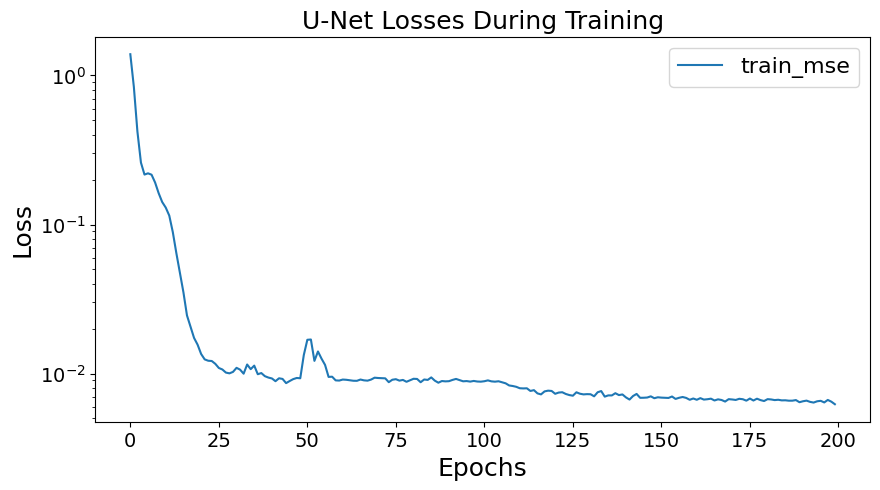

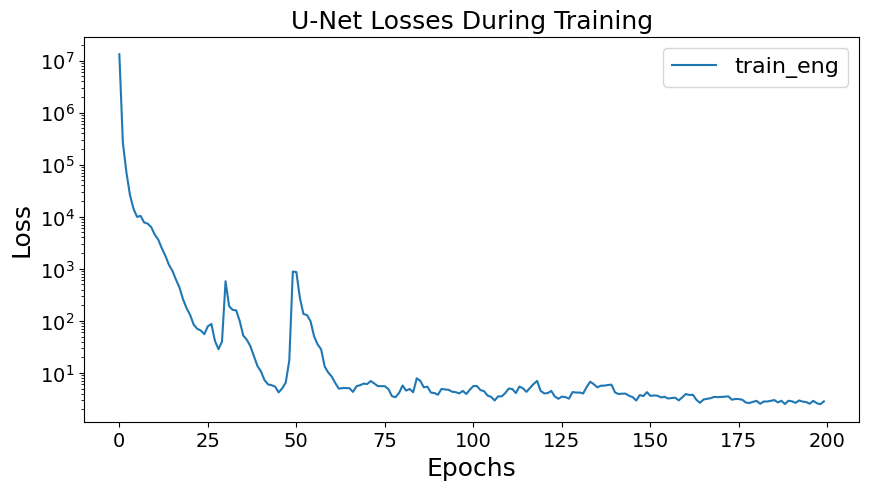

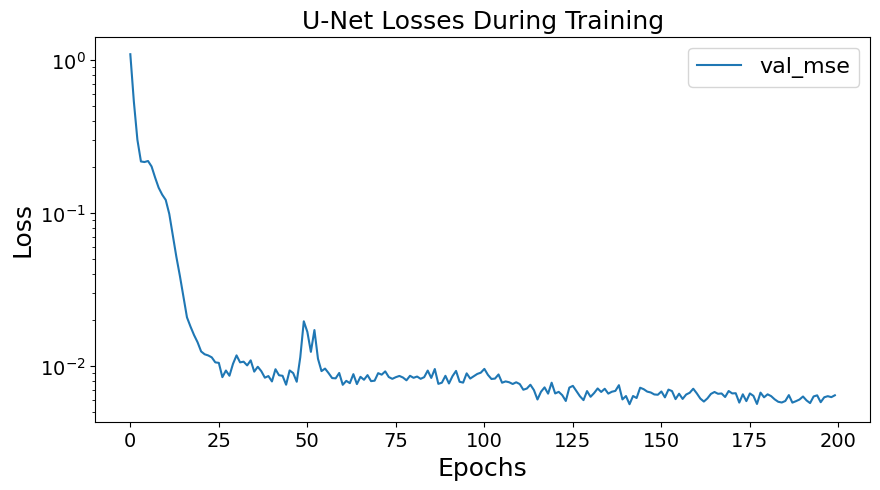

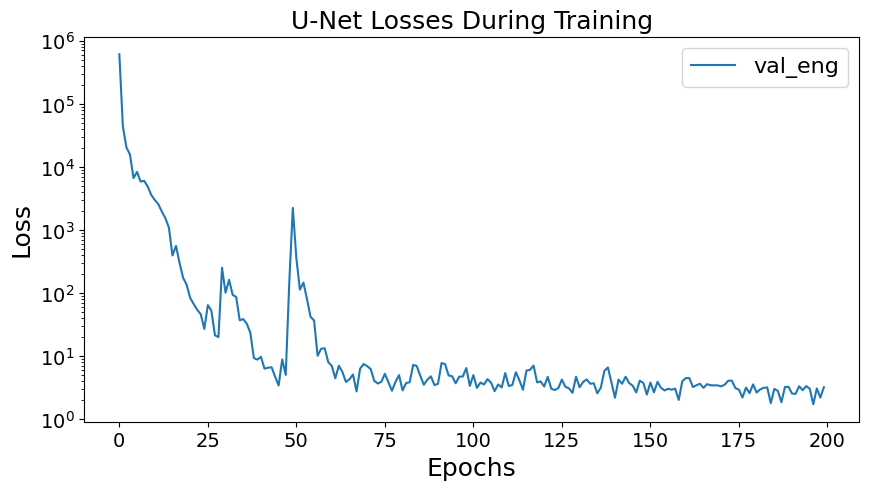

In [12]:
# Visualize training
unet_results = torch.load(config["main_dir"] + "Train_Results/unet_outputs.pth")

if config["start_epoch"] != 0:
  checkpoint_path = os.path.join(config["main_dir"], f"Train_Results/checkpoint_epoch_{config["start_epoch"]}.pth")
  prev = torch.load(checkpoint_path, map_location="cpu")

  # Merge previous results with current training run
  unet_results["train_losses"] = prev["train_losses"] + unet_results["train_losses"]
  unet_results["train_mse"] = prev["train_mse"] + unet_results["train_mse"]
  unet_results["train_dc"] = prev["train_res"] + unet_results["train_res"]
  unet_results["val_losses"] = prev["val_losses"] + unet_results["val_losses"]
  unet_results["val_mse"] = prev["val_mse"] + unet_results["val_mse"]
  unet_results["val_res"] = prev["val_res"] + unet_results["val_res"]

losses = {
  "train_mse": unet_results["train_mse"],
  "train_eng": unet_results["train_eng"],
  "val_mse": unet_results["val_mse"],
  "val_eng": unet_results["val_eng"],
}
for loss in losses:
  plt.figure(figsize=(10,5))
  plt.title("U-Net Losses During Training")
  plt.plot(losses[loss], label=loss)
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.yscale("log")
  plt.legend()
  plt.show()

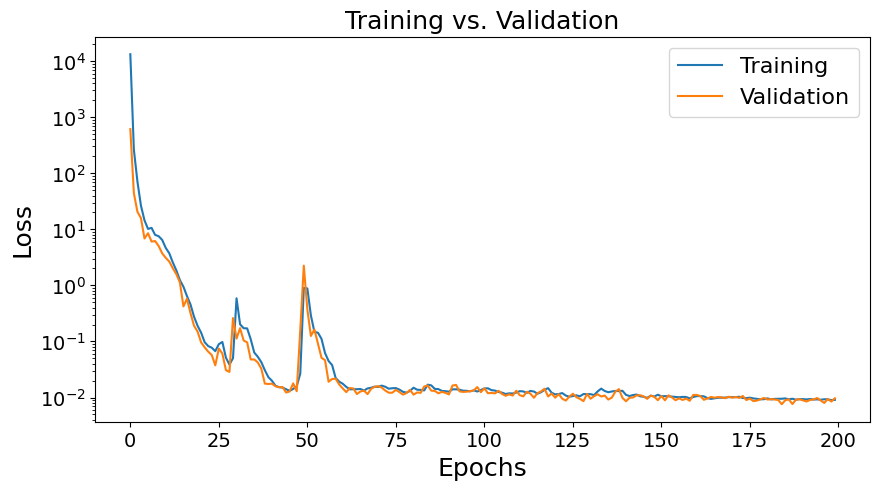

In [13]:
plt.figure(figsize=(10,5))
plt.title("Training vs. Validation")
plt.plot(unet_results["train_losses"], label="Training")
plt.plot(unet_results["val_losses"], label="Validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [14]:
def plot_traction_field(tensor, L, W):
    """
    Plots contour maps of traction components.

    tensor: [2, nx, ny] traction tensor
    L, W: beam length and width
    """

    tx = tensor[0].cpu()
    ty = tensor[1].cpu()

    nx, ny = tx.shape

    x = torch.linspace(0, L, nx)
    y = torch.linspace(0, W, ny)

    X, Y = torch.meshgrid(x, y, indexing='ij')

    fig, axs = plt.subplots(1, 2, figsize=(12,4))

    c1 = axs[0].contourf(X, Y, tx, levels=20)
    fig.colorbar(c1, ax=axs[0])
    axs[0].set_title("Traction $t_x$")
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("y")

    c2 = axs[1].contourf(X, Y, ty, levels=20)
    fig.colorbar(c2, ax=axs[1])
    axs[1].set_title("Traction $t_y$")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("y")

    plt.tight_layout()
    plt.show()

In [15]:
# Plot testing samples
idx = [187, 0, 261]
samples = [test_dataset[i] for i in idx]
nodes_list, t_list, u_list = zip(*samples)

nodes_test = torch.stack(nodes_list, dim=0).to(device)
t_test = torch.stack(t_list, dim=0).to(device)
u_test = torch.stack(u_list, dim=0).to(device)
inp = torch.cat([nodes_test, t_test], dim=1)

with torch.no_grad():
    u_pred = model(inp)


=== Sample 1 ===


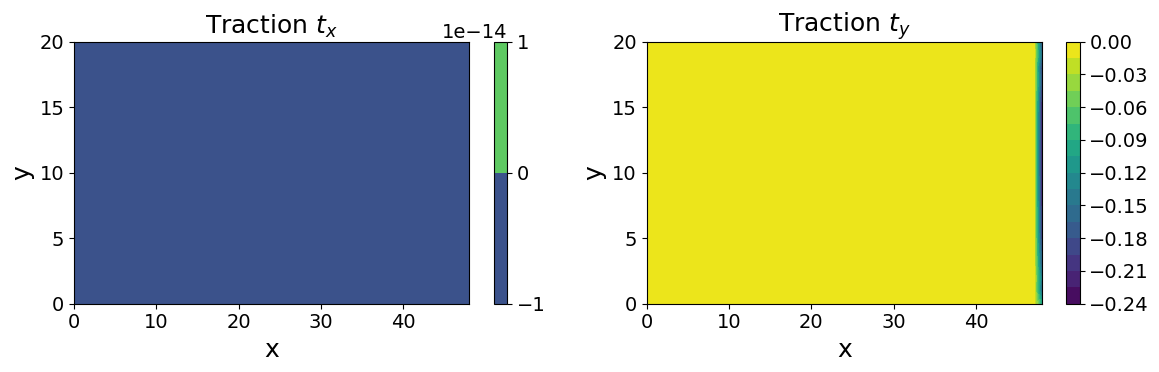

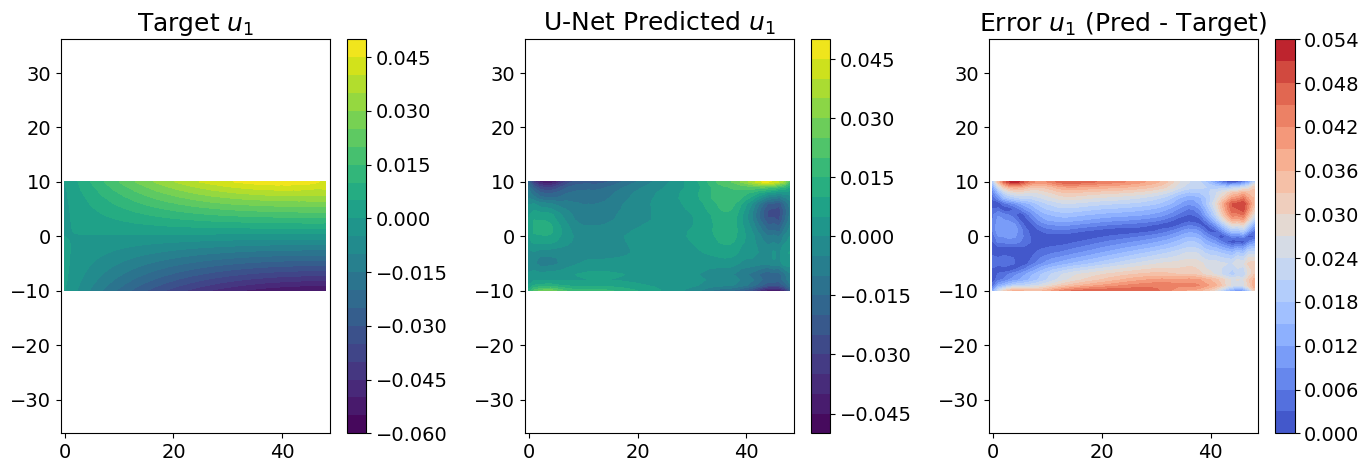

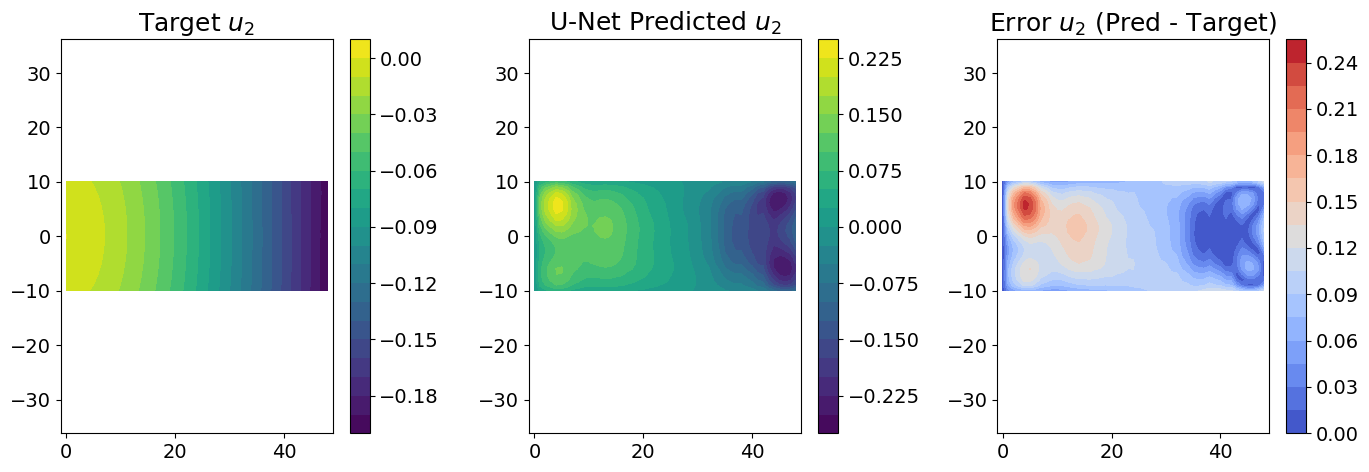

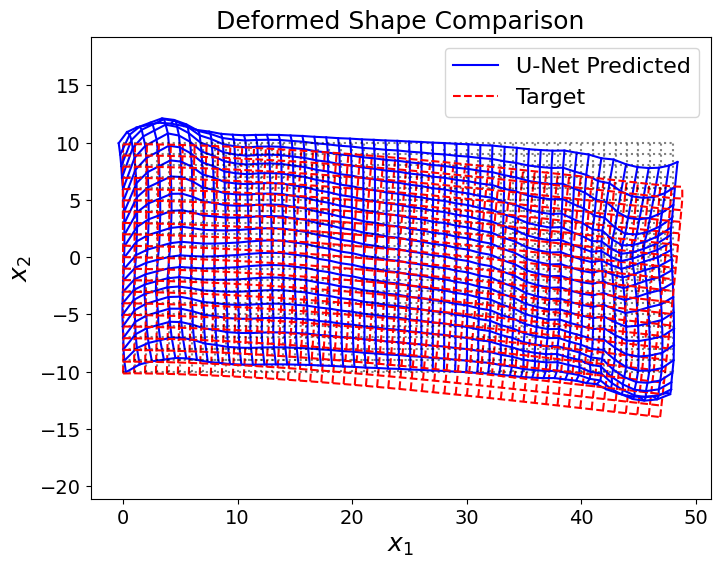

=== Sample 2 ===


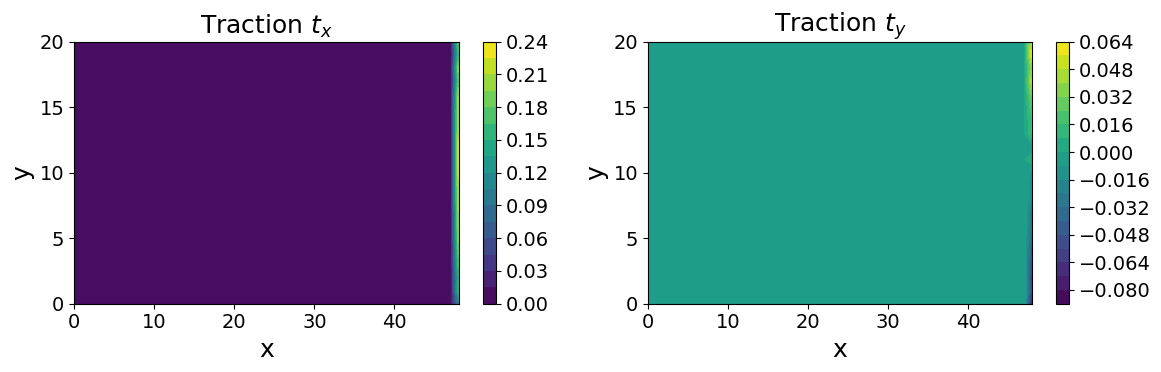

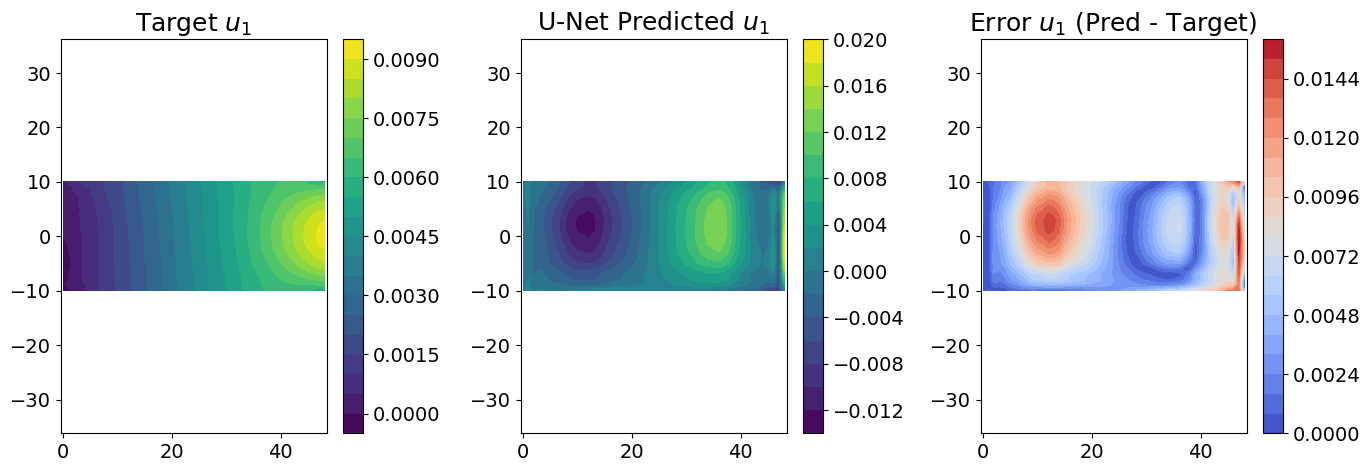

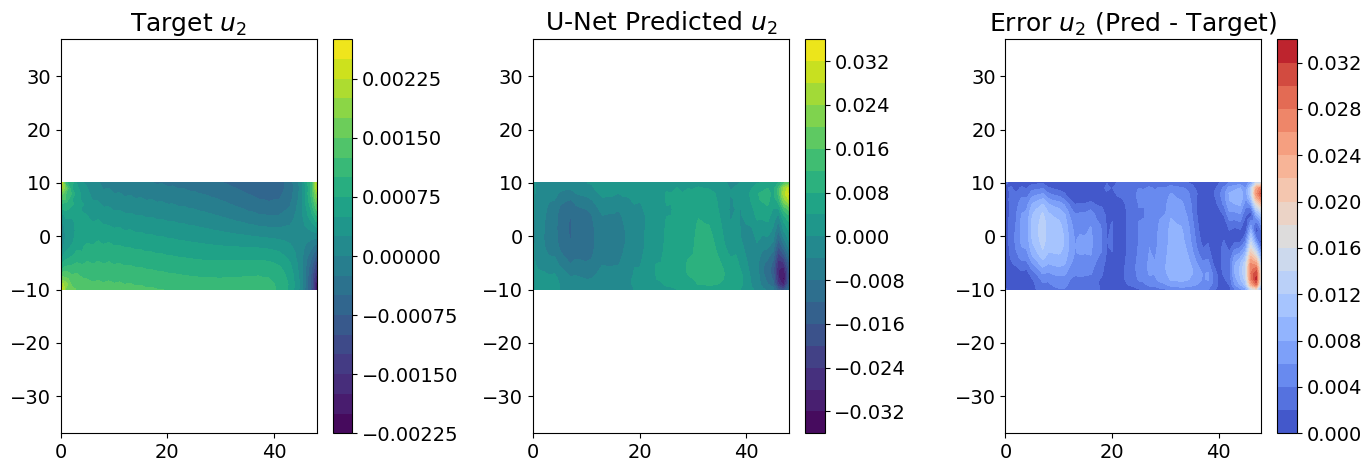

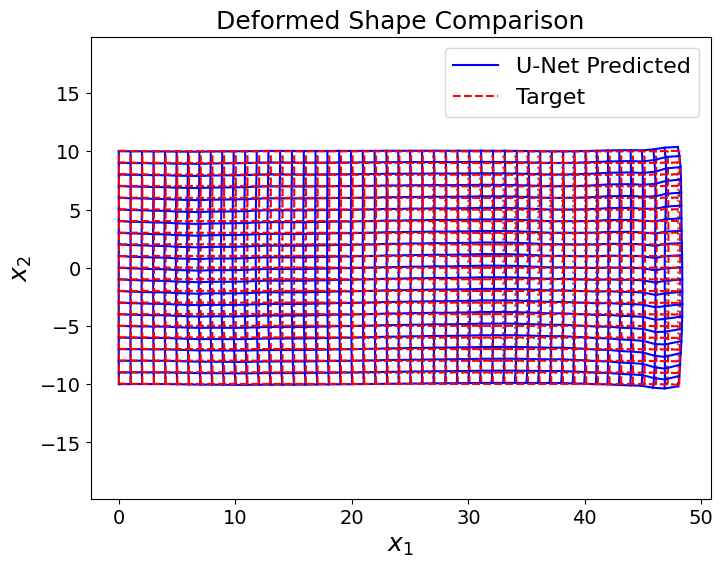

=== Sample 3 ===


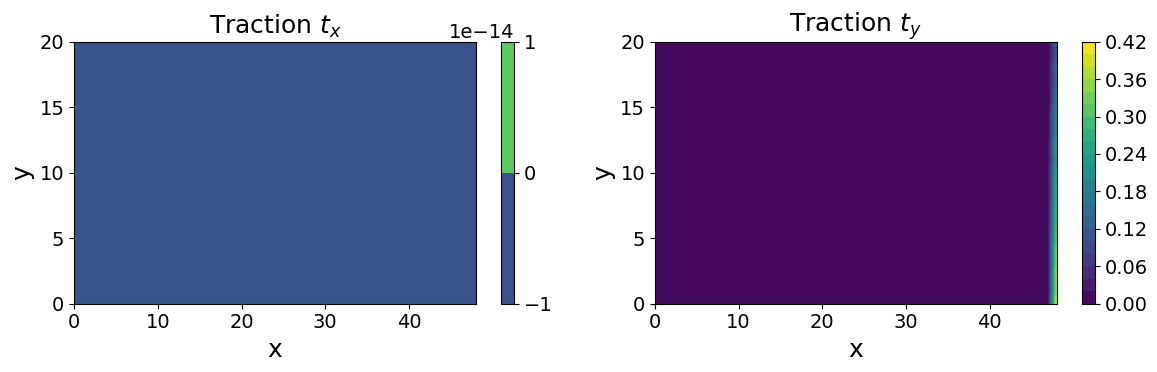

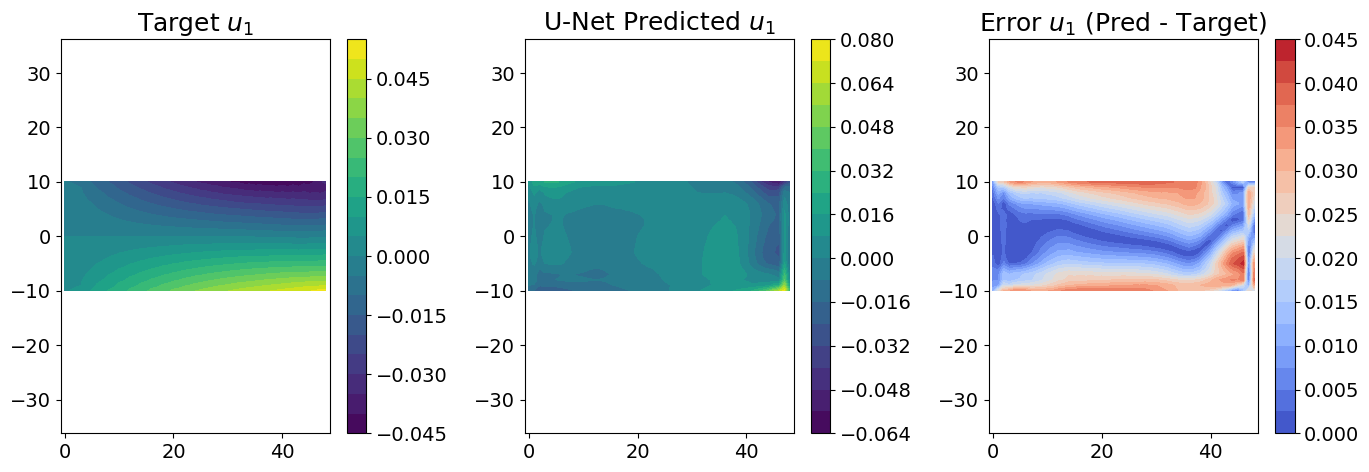

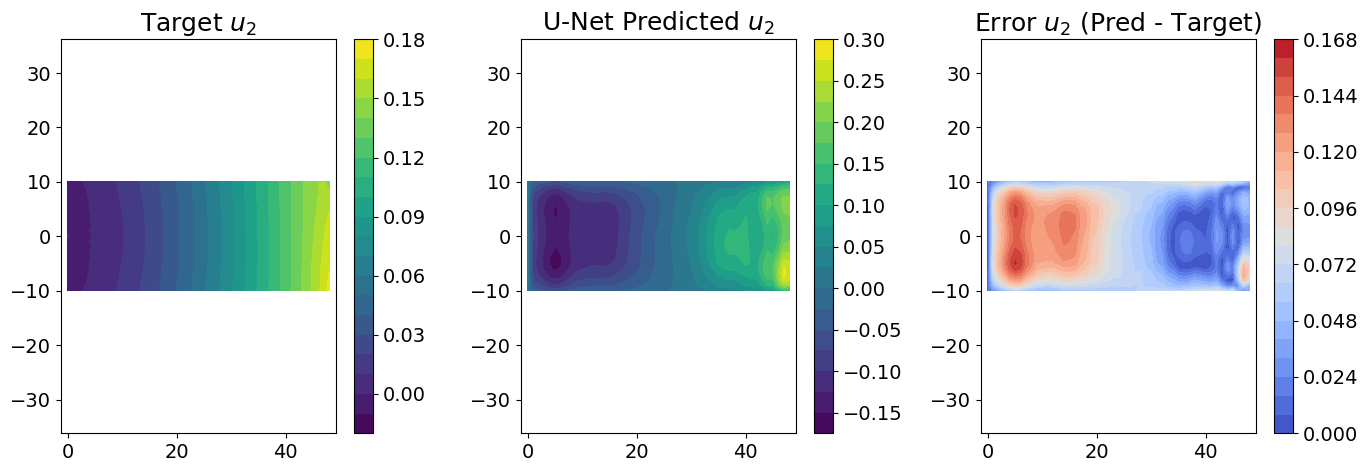

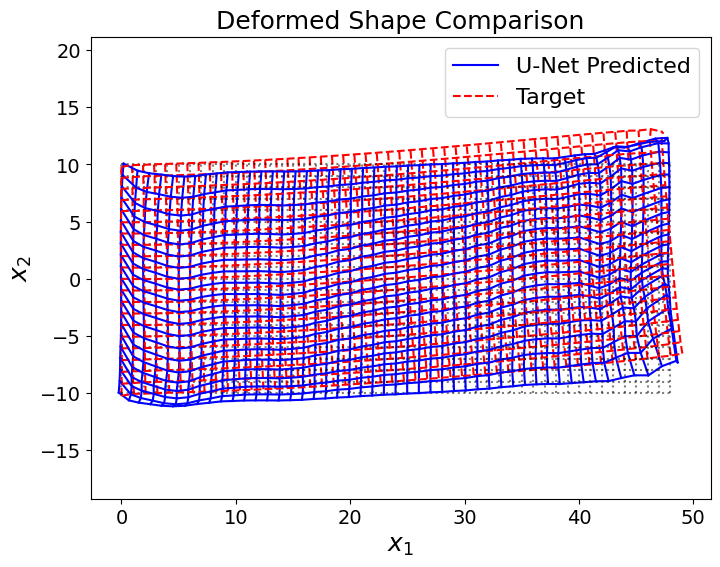

In [16]:
for i in range(u_pred.shape[0]):
    print(f"=== Sample {i+1} ===")
    u_pred_i = u_pred[i]
    u_target_i = u_test[i]

    # Echo tractions
    t_test_i = t_test[i]
    plot_traction_field(t_test_i, L, W)

    # Plot side-by-side comparison and error
    plot_pred_vs_target(u_pred_i, u_target_i, L, W, "U-Net")

    # Plot deformed shape comparison
    plot_deformed_comparison(u_pred_i, u_target_i, L, W, "U-Net", scale=20.0)

In [17]:
# Quantitative metrics
mse = torch.nn.MSELoss()
loss_mse, loss_res = [], []
for i in range(len(test_dataset) // config["batch_size"]):
  nodes_test, t_test, u_test = test_dataset[i]
  nodes_test = nodes_test.unsqueeze(0).to(device)
  t_test = t_test.unsqueeze(0).to(device)
  u_test = u_test.unsqueeze(0).to(device)

  with torch.no_grad():
    inp = torch.cat([nodes_test, t_test], dim=1).to(device)
    u_pred = model(inp)

  # MSE
  loss_mse.append(mse(u_pred, u_test.to(device)))

  # Residual/Energy
  loss_res.append(test_energy_loss(u_pred.cpu(), u_test.cpu(), D, t_test.cpu()))

print(f"MSE: {torch.stack(loss_mse).mean().item()}")
print(f"Energy Loss: {torch.stack(loss_res).mean().item()}")

MSE: 4.5136737753637135e-05
Energy Loss: 0.6770373582839966


In [18]:
from google.colab import runtime
runtime.unassign()